In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.1


In [ ]:
BASE_DIR = Path("../Dados")
TESTE_DIR = BASE_DIR / "Teste"
MODELOS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
CLASSES = ["nowildfire", "wildfire"]

# Carrega os 2 modelos salvos
modelo_baseline = tf.keras.models.load_model(MODELOS_DIR / "modelo_baseline_melhor.keras")
modelo_avancado = tf.keras.models.load_model(MODELOS_DIR / "modelo_avancado_melhor.keras")

print(" Modelos carregados")
print(f"   Baseline: {modelo_baseline.count_params():,} parâmetros")
print(f"   Avançado: {modelo_avancado.count_params():,} parâmetros")

2026-06-02 10:59:23.371897: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-02 10:59:23.372508: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 10:59:23.372748: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780408763.373153 1872961 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780408763.373286 1872961 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Modelos carregados
   Baseline: 4,287,809 parâmetros
   Avançado: 423,265 parâmetros


In [3]:
with open(REPORTS_DIR / "metricas_baseline.json", "r") as f:
    metricas_baseline = json.load(f)

with open(REPORTS_DIR / "metricas_avancado.json", "r") as f:
    metricas_avancado = json.load(f)

print(f"Baseline:  {metricas_baseline['test_accuracy']*100:.2f}% acurácia | {metricas_baseline['epochs_treinadas']} épocas | {metricas_baseline['tempo_minutos']:.1f} min")
print(f"Avançado:  {metricas_avancado['test_accuracy']*100:.2f}% acurácia | {metricas_avancado['epochs_treinadas']} épocas | {metricas_avancado['tempo_minutos']:.1f} min")

Baseline:  73.79% acurácia | 9 épocas | 7.8 min
Avançado:  97.30% acurácia | 15 épocas | 26.8 min


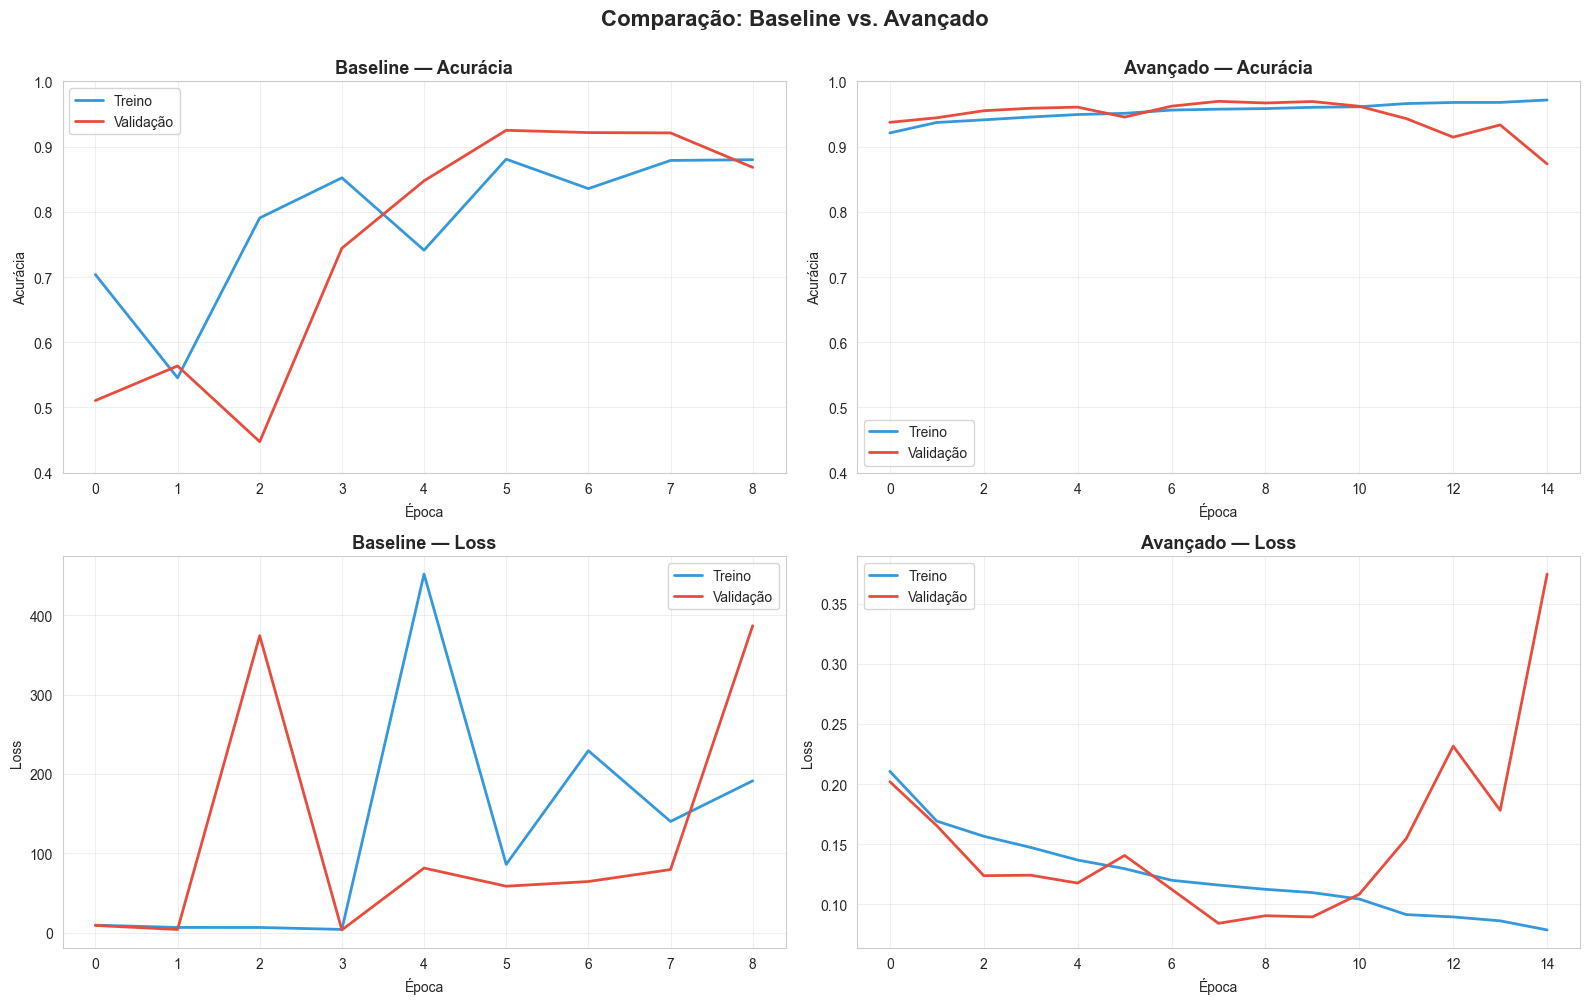

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Linha 1: Acurácia
axes[0, 0].plot(metricas_baseline["historico"]["accuracy"], label="Treino", linewidth=2, color="#3498db")
axes[0, 0].plot(metricas_baseline["historico"]["val_accuracy"], label="Validação", linewidth=2, color="#e74c3c")
axes[0, 0].set_title("Baseline — Acurácia", fontweight="bold", fontsize=13)
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("Acurácia")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0.4, 1.0)

axes[0, 1].plot(metricas_avancado["historico"]["accuracy"], label="Treino", linewidth=2, color="#3498db")
axes[0, 1].plot(metricas_avancado["historico"]["val_accuracy"], label="Validação", linewidth=2, color="#e74c3c")
axes[0, 1].set_title("Avançado — Acurácia", fontweight="bold", fontsize=13)
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Acurácia")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(0.4, 1.0)

# Linha 2: Loss
axes[1, 0].plot(metricas_baseline["historico"]["loss"], label="Treino", linewidth=2, color="#3498db")
axes[1, 0].plot(metricas_baseline["historico"]["val_loss"], label="Validação", linewidth=2, color="#e74c3c")
axes[1, 0].set_title("Baseline — Loss", fontweight="bold", fontsize=13)
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metricas_avancado["historico"]["loss"], label="Treino", linewidth=2, color="#3498db")
axes[1, 1].plot(metricas_avancado["historico"]["val_loss"], label="Validação", linewidth=2, color="#e74c3c")
axes[1, 1].set_title("Avançado — Loss", fontweight="bold", fontsize=13)
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Comparação: Baseline vs. Avançado", fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "comparacao_curvas.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TESTE_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Extrai labels verdadeiros (antes de transformar o dataset)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0).flatten().astype(int)

# Para o Baseline: precisa normalizar (foi treinado com pixels /255 no pipeline)
test_ds_normalized = test_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
test_ds_normalized = test_ds_normalized.prefetch(tf.data.AUTOTUNE)

# Para o Avançado: NÃO normaliza (Rescaling está dentro do modelo)
test_ds_raw = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"Total de imagens de teste: {len(y_true):,}")
print(f"Distribuição: nowildfire={np.sum(y_true==0):,} | wildfire={np.sum(y_true==1):,}")

# Predições
print("\n Gerando predições do Baseline...")
probs_baseline = modelo_baseline.predict(test_ds_normalized, verbose=1).flatten()
y_pred_baseline = (probs_baseline > 0.5).astype(int)

print("\n Gerando predições do Avançado...")
probs_avancado = modelo_avancado.predict(test_ds_raw, verbose=1).flatten()
y_pred_avancado = (probs_avancado > 0.5).astype(int)

print("\n✅Predições prontas!")

Found 6299 files belonging to 2 classes.


2026-06-02 10:59:37.219865: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-02 10:59:37.260712: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Total de imagens de teste: 6,299
Distribuição: nowildfire=2,820 | wildfire=3,479

🔄 Gerando predições do Baseline...
197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

🔄 Gerando predições do Avançado...
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step

✅ Predições prontas!


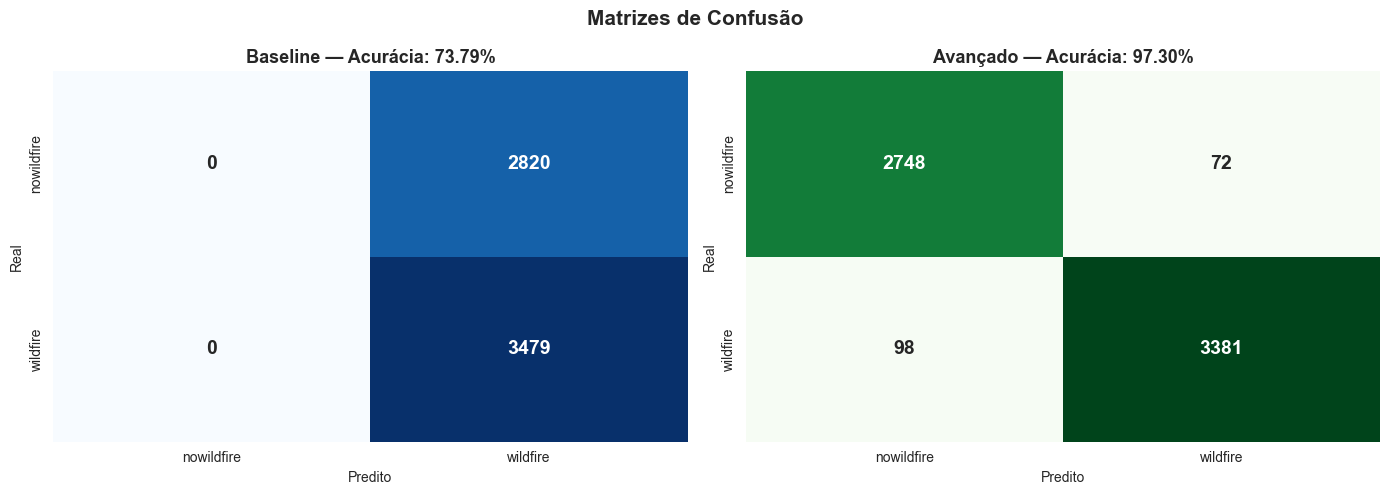

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
cm_baseline = confusion_matrix(y_true, y_pred_baseline)
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"Baseline — Acurácia: {metricas_baseline['test_accuracy']*100:.2f}%",
                  fontweight="bold", fontsize=13)
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predito")

# Avançado
cm_avancado = confusion_matrix(y_true, y_pred_avancado)
sns.heatmap(cm_avancado, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title(f"Avançado — Acurácia: {metricas_avancado['test_accuracy']*100:.2f}%",
                  fontweight="bold", fontsize=13)
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predito")

plt.suptitle("Matrizes de Confusão", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "matrizes_confusao.png", dpi=100, bbox_inches="tight")
plt.show()

In [1]:

print("MODELO BASELINE")

print(classification_report(y_true, y_pred_baseline, target_names=CLASSES, digits=4))


print("MODELO AVANÇADO")

print(classification_report(y_true, y_pred_avancado, target_names=CLASSES, digits=4))

MODELO BASELINE


NameError: name 'classification_report' is not defined

In [ ]:
def calcular_metricas(y_true, y_pred):
    return {
        "Acurácia": (y_pred == y_true).mean(),
        "Precision (nowildfire)": precision_score(y_true, y_pred, pos_label=0),
        "Recall (nowildfire)": recall_score(y_true, y_pred, pos_label=0),
        "F1 (nowildfire)": f1_score(y_true, y_pred, pos_label=0),
        "Precision (wildfire)": precision_score(y_true, y_pred, pos_label=1),
        "Recall (wildfire)": recall_score(y_true, y_pred, pos_label=1),
        "F1 (wildfire)": f1_score(y_true, y_pred, pos_label=1),
    }

m_base = calcular_metricas(y_true, y_pred_baseline)
m_av = calcular_metricas(y_true, y_pred_avancado)

df_comparativo = pd.DataFrame({
    "Métrica": list(m_base.keys()),
    "Baseline": [f"{v:.4f}" for v in m_base.values()],
    "Avançado": [f"{v:.4f}" for v in m_av.values()],
    "Melhoria (pp)": [f"{(m_av[k] - m_base[k])*100:+.2f}" for k in m_base.keys()],
})

print(df_comparativo.to_string(index=False))

# Salva como CSV
df_comparativo.to_csv(REPORTS_DIR / "tabela_comparativa.csv", index=False)
print(f"\n Tabela salva em reports/tabela_comparativa.csv")

               Métrica Baseline Avançado Melhoria (pp)
              Acurácia   0.5523   0.9730        +42.07
Precision (nowildfire)   0.0000   0.9656        +96.56
   Recall (nowildfire)   0.0000   0.9745        +97.45
       F1 (nowildfire)   0.0000   0.9700        +97.00
  Precision (wildfire)   0.5523   0.9791        +42.68
     Recall (wildfire)   1.0000   0.9718         -2.82
         F1 (wildfire)   0.7116   0.9755        +26.39

✅ Tabela salva em reports/tabela_comparativa.csv


/Users/guilhermevargas/Documents/GlobalSolution/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


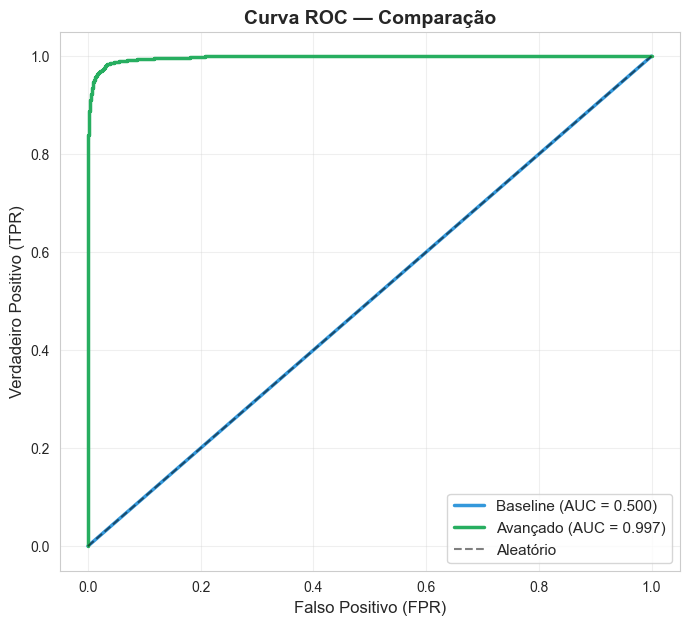

In [9]:
fpr_b, tpr_b, _ = roc_curve(y_true, probs_baseline)
fpr_a, tpr_a, _ = roc_curve(y_true, probs_avancado)
auc_b = auc(fpr_b, tpr_b)
auc_a = auc(fpr_a, tpr_a)

plt.figure(figsize=(8, 7))
plt.plot(fpr_b, tpr_b, label=f"Baseline (AUC = {auc_b:.3f})", linewidth=2.5, color="#3498db")
plt.plot(fpr_a, tpr_a, label=f"Avançado (AUC = {auc_a:.3f})", linewidth=2.5, color="#27ae60")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
plt.xlabel("Falso Positivo (FPR)", fontsize=12)
plt.ylabel("Verdadeiro Positivo (TPR)", fontsize=12)
plt.title("Curva ROC — Comparação", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(REPORTS_DIR / "curva_roc.png", dpi=100, bbox_inches="tight")
plt.show()

Total de erros do Modelo Avançado: 170 de 6299 (2.70%)


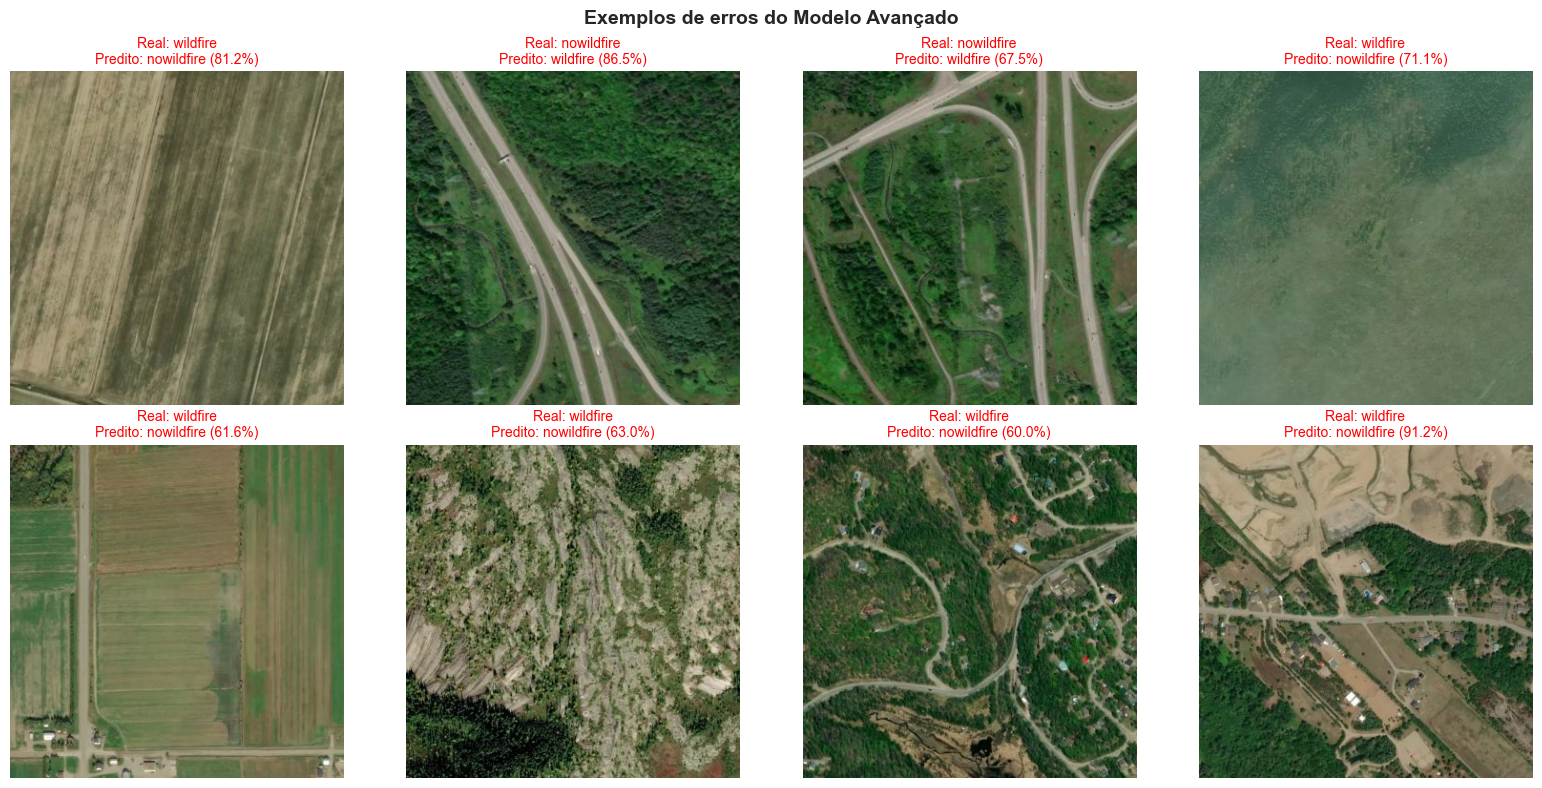

In [10]:
# Coleta imagens do conjunto de teste com paths e os erros do modelo avançado
arquivos_teste = []
for classe_idx, classe in enumerate(CLASSES):
    pasta = TESTE_DIR / classe
    for arq in sorted(pasta.iterdir()):
        arquivos_teste.append((arq, classe_idx))

# IMPORTANTE: precisa garantir mesma ordem do dataset
# image_dataset_from_directory ordena alfabeticamente por classe, depois por nome
arquivos_teste = sorted(arquivos_teste, key=lambda x: (x[1], x[0].name))
paths_teste = [a[0] for a in arquivos_teste]

# Encontra índices onde o modelo errou
indices_erros = np.where(y_pred_avancado != y_true)[0]
print(f"Total de erros do Modelo Avançado: {len(indices_erros)} de {len(y_true)} ({len(indices_erros)/len(y_true)*100:.2f}%)")

# Mostra até 8 exemplos de erros
n_mostrar = min(8, len(indices_erros))
indices_amostra = np.random.choice(indices_erros, n_mostrar, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(indices_amostra):
    img = Image.open(paths_teste[idx])
    axes[i].imshow(img)
    real = CLASSES[y_true[idx]]
    predito = CLASSES[y_pred_avancado[idx]]
    confianca = probs_avancado[idx] if y_pred_avancado[idx] == 1 else 1 - probs_avancado[idx]
    axes[i].set_title(f"Real: {real}\nPredito: {predito} ({confianca*100:.1f}%)",
                      fontsize=10, color="red")
    axes[i].axis("off")

plt.suptitle("Exemplos de erros do Modelo Avançado", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "analise_erros.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:

print("RESUMO FINAL — COMPARAÇÃO DE MODELOS")

print(f"""
 MODELO 1 — BASELINE
   Arquitetura: 3 blocos Conv2D + MaxPool, sem regularização
   Parâmetros:  {modelo_baseline.count_params():,}
   Test Accuracy: {metricas_baseline['test_accuracy']*100:.2f}%
   AUC: {auc_b:.4f}
   Comportamento: instável (loss explodindo)

 MODELO 2 — AVANÇADO
   Arquitetura: 4 blocos Conv2D + BatchNorm + Dropout + GAP + Augmentation
   Parâmetros:  {modelo_avancado.count_params():,}
   Test Accuracy: {metricas_avancado['test_accuracy']*100:.2f}%
   AUC: {auc_a:.4f}
   Comportamento: estável, com convergência suave

 VENCEDOR: Modelo Avançado
   Melhoria absoluta: +{(metricas_avancado['test_accuracy'] - metricas_baseline['test_accuracy'])*100:.2f} pontos percentuais
   Meta de 88%: {'✅ ATINGIDA' if metricas_avancado['test_accuracy'] >= 0.88 else '❌ NÃO ATINGIDA'}

 TÉCNICAS QUE FIZERAM DIFERENÇA:
   1. Batch Normalization → estabilizou gradientes
   2. Dropout progressivo (0.2→0.5) → reduziu overfitting
   3. Global Average Pooling → menos parâmetros densos
   4. Data Augmentation → mais robustez
   5. ReduceLROnPlateau → ajuste dinâmico do LR
""")


RESUMO FINAL — COMPARAÇÃO DE MODELOS

📊 MODELO 1 — BASELINE
   Arquitetura: 3 blocos Conv2D + MaxPool, sem regularização
   Parâmetros:  4,287,809
   Test Accuracy: 73.79%
   AUC: 0.5000
   Comportamento: instável (loss explodindo)

📊 MODELO 2 — AVANÇADO
   Arquitetura: 4 blocos Conv2D + BatchNorm + Dropout + GAP + Augmentation
   Parâmetros:  423,265
   Test Accuracy: 97.30%
   AUC: 0.9972
   Comportamento: estável, com convergência suave

🏆 VENCEDOR: Modelo Avançado
   Melhoria absoluta: +23.51 pontos percentuais
   Meta de 88%: ✅ ATINGIDA

🔑 TÉCNICAS QUE FIZERAM DIFERENÇA:
   1. Batch Normalization → estabilizou gradientes
   2. Dropout progressivo (0.2→0.5) → reduziu overfitting
   3. Global Average Pooling → menos parâmetros densos
   4. Data Augmentation → mais robustez
   5. ReduceLROnPlateau → ajuste dinâmico do LR

